In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from typing import Literal
from pydantic import BaseModel
import yfinance as yf
from langgraph.prebuilt import create_react_agent,ToolNode,tools_condition
from dotenv import load_dotenv

c:\Users\akash\OneDrive\Desktop\finance_analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

NORMAL LLM

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

STATE

In [4]:

from typing import TypedDict,Annotated
import operator

class FinancialState(TypedDict):
    query: str
    route: str

    company: str
    ticker: str

    response: str

    agent_outputs: dict

    messages: Annotated[list, operator.add]

PYDANTIC MODEL

In [5]:
class RouteDecision(BaseModel):
    route: Literal["market_agent"]

In [6]:
class CompanyExtraction(BaseModel):
    company: str

STRUCTURE MODEL

In [7]:
router_llm = llm.with_structured_output(RouteDecision)

In [8]:
extractor_llm = llm.with_structured_output(
    CompanyExtraction
)

HELPER FUNCTION

In [9]:
def fetch_company_info(symbol: str):

    stock = yf.Ticker(symbol)

    return stock.info

TOOLS TO BE USED

In [10]:
@tool
def get_stock_data(ticker: str):
    """
    Fetch live stock information using Yahoo Finance.
    """
    try:
        info = fetch_company_info(ticker)

        return {
            "company": info.get("longName", "N/A"),
            "symbol": info.get("symbol", ticker),
            "current_price": info.get("currentPrice", "N/A"),
            "previous_close": info.get("previousClose", "N/A"),
            "market_cap": info.get("marketCap", "N/A"),
            "sector": info.get("sector", "N/A"),
            "industry": info.get("industry", "N/A"),
            "pe_ratio": info.get("trailingPE", "N/A"),
            "eps": info.get("trailingEps", "N/A"),
            "currency": info.get("currency", "N/A"),
        }

    except Exception as e:
        return {
            "error": str(e)
        }

In [11]:
@tool
def get_company_profile(ticker: str):
    """
    Fetch company profile information using Yahoo Finance.
    """

    info = fetch_company_info(ticker)

    return {
        "company": info.get("longName"),
        "industry": info.get("industry"),
        "sector": info.get("sector"),
        "website": info.get("website"),
        "country": info.get("country"),
        "employees": info.get("fullTimeEmployees"),
        "business_summary": info.get("longBusinessSummary"),
    }

In [12]:
@tool
def calculate_financial_ratios(ticker: str):
    """
    Fetch important financial ratios.
    """

    info = fetch_company_info(ticker)

    return {
        "pe_ratio": info.get("trailingPE"),
        "forward_pe": info.get("forwardPE"),
        "peg_ratio": info.get("pegRatio"),
        "price_to_book": info.get("priceToBook"),
        "profit_margin": info.get("profitMargins"),
        "operating_margin": info.get("operatingMargins"),
        "return_on_equity": info.get("returnOnEquity"),
        "return_on_assets": info.get("returnOnAssets"),
    }

REACT AGENT

In [13]:
market_react_agent = create_react_agent(
    model=llm,
    tools=[
        get_stock_data,
        get_company_profile,
        calculate_financial_ratios
    ]
)

C:\Users\akash\AppData\Local\Temp\ipykernel_16892\4053900193.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  market_react_agent = create_react_agent(


NODE FUNCTION

In [14]:
def supervisor_agent(state: FinancialState):
    query = state["query"]

    prompt = f"""
        You are a routing agent.

        Choose which agent should answer the user's query.

        Available agents:

        market_agent

        Return ONLY the agent name.

        User Query:
        {query}
    """
    decision = router_llm.invoke(prompt)
    print(decision)
    return {
        "route": decision.route
    }

In [15]:
def market_agent(state: FinancialState):

    ticker = state["ticker"]

    result = market_react_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"""
                            You are a professional financial analyst.

                            Analyze the company using the ticker:

                            {ticker}

                            Use your available tools whenever required.

                            After retrieving the data, provide:

                            1. Company Overview
                            2. Current Stock Price
                            3. Market Capitalization
                            4. Sector
                            5. P/E Ratio
                            6. EPS

                            Keep the response under 200 words.
                        """
                )
            ]
        }
    )

    final_answer = result["messages"][-1].content

    last_message = result["messages"][-1]

    if isinstance(last_message.content, list):
        final_answer = "\n".join(
            block["text"]
            for block in last_message.content
            if block.get("type") == "text"
        )
    else:
        final_answer = last_message.content

    market_output = {
        "analysis": final_answer
    }

    return {
        "response": final_answer,
        "agent_outputs": {
            "market": market_output
        },
        "messages": result["messages"]
    }

In [16]:
def router(state: FinancialState):
    return state["route"]

In [17]:
def entity_extractor_agent(state: FinancialState):

    query = state["query"]
    prompt = f"""
        You are a financial entity extraction agent.

        Extract ONLY the company name mentioned.

        Examples

        Input:
        Should I invest in Apple?

        Output:
        Apple

        Input:
        Analyze Microsoft stock.

        Output:
        Microsoft

        Input:
        Tell me about Tesla.

        Output:
        Tesla

        User Query:

        {query}
    """

    result = extractor_llm.invoke(prompt)
    print(f"\nCompany: {result.company}")
    return {
        "company": result.company
    }

In [18]:
TICKER_MAP = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Google": "GOOGL",
    "Alphabet": "GOOGL",
    "Amazon": "AMZN",
    "Tesla": "TSLA",
    "Meta": "META",
    "NVIDIA": "NVDA",
    "Netflix": "NFLX",
    "Intel": "INTC",
    "AMD": "AMD",

    "Reliance": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
    "Wipro": "WIPRO.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "ICICI Bank": "ICICIBANK.NS",
}

In [19]:
def ticker_resolver_agent(state: FinancialState):

    company = state["company"]

    ticker = TICKER_MAP.get(company)

    if ticker is None:
        ticker = company

    print(f"\nTicker: {ticker}")

    return {
        "ticker": ticker
    }

GRAPH BUILDING

In [20]:
builder = StateGraph(FinancialState)

#nodes
builder.add_node("supervisor", supervisor_agent)
builder.add_node("market_agent", market_agent)
builder.add_node("entity_extractor",entity_extractor_agent)
builder.add_node("ticker_resolver",ticker_resolver_agent)

#edges
builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    router,
    {
        "market_agent": "entity_extractor"
    }
)
builder.add_edge("entity_extractor","ticker_resolver")
builder.add_edge("ticker_resolver","market_agent")
builder.add_edge("market_agent", END)

graph = builder.compile()

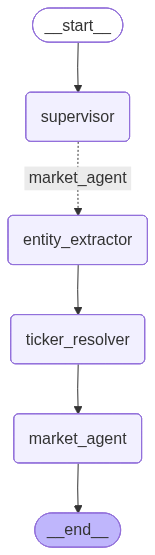

In [21]:
graph

In [22]:
query = "Analyze Apple"
result = graph.invoke(
    {
        "query": query,
        "route": "",
        "company": "",
        "ticker": "",
        "response": "",
        "agent_outputs": {},
        "messages": []
    }
)

route='market_agent'

Company: Apple

Ticker: AAPL


In [23]:
result

{'query': 'Analyze Apple',
 'route': 'market_agent',
 'company': 'Apple',
 'ticker': 'AAPL',
 'response': "Here's an analysis of Apple Inc. (AAPL):\n\n**1. Company Overview:** Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories globally. They also offer various services like AppleCare, cloud services, and subscription-based platforms such as the App Store, Apple Music, and Apple TV.\n\n**2. Current Stock Price:** $289.36\n\n**3. Market Capitalization:** $4,249,933,053,952\n\n**4. Sector:** Technology\n\n**5. P/E Ratio:** 35.07\n\n**6. EPS:** $8.25",
 'agent_outputs': {'market': {'analysis': "Here's an analysis of Apple Inc. (AAPL):\n\n**1. Company Overview:** Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories globally. They also offer various services like AppleCare, cloud services, and subscription-based platforms such as the App Store, Apple Music, and Apple 